In [1]:
!source /dtu/projects/02613_2025/conda/conda_init.sh
!conda activate 02613_2026

No GPU on this node, CUDA module not loaded
/bin/bash: line 1: conda: command not found


In [2]:
import os

In [3]:
# counting the number of floorplans
def count_floorplans(path):
    files = os.listdir(path)
    return len(files) // 2  # each floorplan has 2 files (_domain and _interior)


def return_IDS(path):
    files = os.listdir(path)
    ids = []
    for filename in files:
        id = filename.split('_')[0]
        if id not in ids:
            ids.append(id)
    return ids

In [4]:
path = "/dtu/projects/02613_2025/data/modified_swiss_dwellings/"
print(count_floorplans(path)) 

ids = return_IDS(path)
print(ids)

4571
['8707', '40684', '2754', '22335', '13858', '3896', '2288', '7914', '5302', '13767', '48197', '11103', '30507', '49818', '11738', '5156', '50547', '2196', '9425', '40078', '3748', '4561', '108', '23556', '45668', '48836', '26079', '2070', '51680', '3895', '45745', '1110', '12881', '3363', '28955', '2695', '3251', '4735', '29755', '45576', '29576', '2975', '9117', '15405', '9835', '24173', '5453', '9768', '4097', '13298', '4672', '13540', '29722', '10801', '6006', '14759', '5994', '10323', '10790', '45751', '2149', '8774', '677', '2893', '8520', '7938', '6085', '47831', '14032', '44570', '4718', '23797', '22855', '50514', '2369', '1640', '5918', '25775', '24468', '3920', '2742', '4723', '28639', '10522', '45753', '29747', '9293', '2595', '49369', '23714', '50537', '2023', '8792', '10249', '10776', '3803', '8549', '15460', '47247', '50544', '6010', '4621', '26471', '51512', '49553', '4750', '546', '15413', '45001', '712', '10705', '14414', '6244', '48289', '45574', '8851', '15136', 

In [5]:
# open the first file of a building 
import numpy as np
# file is path/ID_domain.npy 

def load_floorplan(path, ID):
    file_path = path + str(ID) + "_domain.npy"
    floorplan = np.load(file_path)
    return floorplan

def load_binarymask (path, ID):
    file_path = path + str(ID) + "_interior.npy"
    binarymask = np.load(file_path)
    return binarymask

ID: 8707, floorplan shape: (512, 512), binarymask shape: (512, 512)


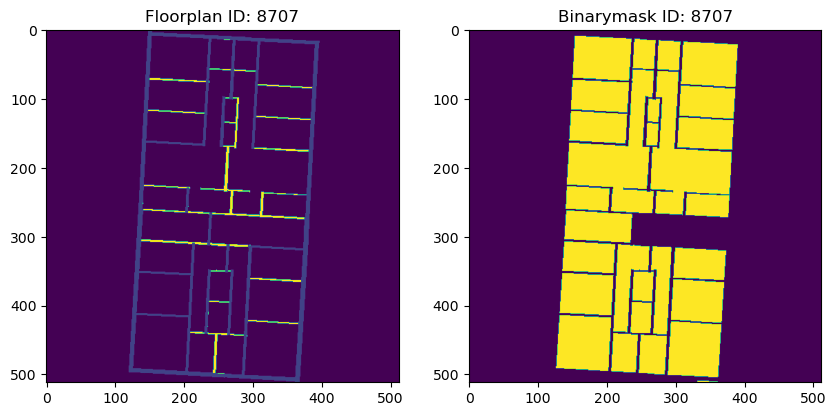

ID: 40684, floorplan shape: (512, 512), binarymask shape: (512, 512)


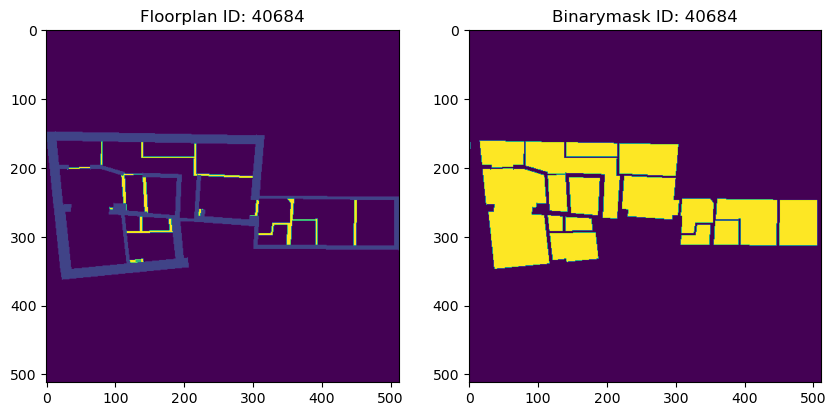

In [6]:
ids_test_1  = ids[0:2] # test the loading of the first 2 files: ids[0] and ids[1]

for id in ids_test_1:
    floorplan = load_floorplan(path, id)
    binarymask = load_binarymask(path, id)
    print(f"ID: {id}, floorplan shape: {floorplan.shape}, binarymask shape: {binarymask.shape}")

    # plot
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(floorplan)
    plt.title(f"Floorplan ID: {id}")
    plt.subplot(1,2,2)
    plt.imshow(binarymask)
    plt.title(f"Binarymask ID: {id}")
    plt.show()

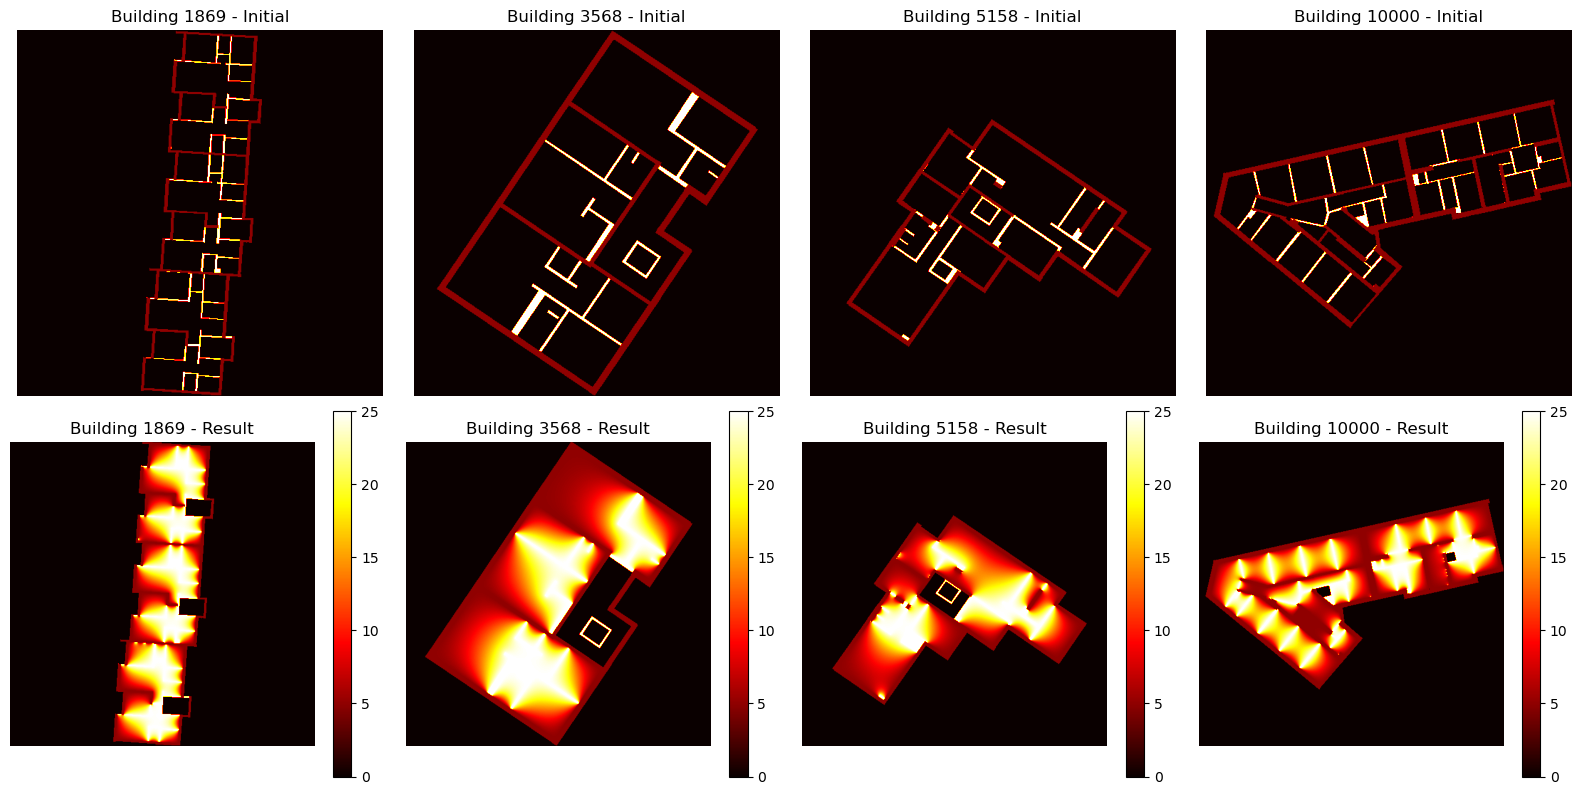

In [7]:
# visualise results for the 5 first floor plans we calculated

import numpy as np
import matplotlib.pyplot as plt
from os.path import join

# Copy the needed functions from simulate.py
LOAD_DIR = '/dtu/projects/02613_2025/data/modified_swiss_dwellings/'

def load_data(load_dir, bid):
    SIZE = 512
    u = np.zeros((SIZE + 2, SIZE + 2))
    u[1:-1, 1:-1] = np.load(join(load_dir, f"{bid}_domain.npy"))
    interior_mask = np.load(join(load_dir, f"{bid}_interior.npy"))
    return u, interior_mask

def jacobi(u, interior_mask, max_iter, atol=1e-6):
    u = np.copy(u)
    for i in range(max_iter):
        u_new = 0.25 * (u[1:-1, :-2] + u[1:-1, 2:] + u[:-2, 1:-1] + u[2:, 1:-1])
        u_new_interior = u_new[interior_mask]
        delta = np.abs(u[1:-1, 1:-1][interior_mask] - u_new_interior).max()
        u[1:-1, 1:-1][interior_mask] = u_new_interior
        if delta < atol:
            break
    return u

# Pick a few building IDs (from your earlier ls output)
building_ids = ['1869', '3568', '5158', '10000']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, bid in enumerate(building_ids):
    u0, interior_mask = load_data(LOAD_DIR, bid)
    u = jacobi(u0, interior_mask, max_iter=20_000, atol=1e-4)
    
    # Plot initial conditions
    axes[0, i].imshow(u0, cmap='hot')
    axes[0, i].set_title(f'Building {bid} - Initial')
    axes[0, i].axis('off')
    
    # Plot simulation result
    im = axes[1, i].imshow(u, cmap='hot')
    axes[1, i].set_title(f'Building {bid} - Result')
    axes[1, i].axis('off')
    plt.colorbar(im, ax=axes[1, i])

plt.tight_layout()
plt.show()


Coldest vs warmest floorplan

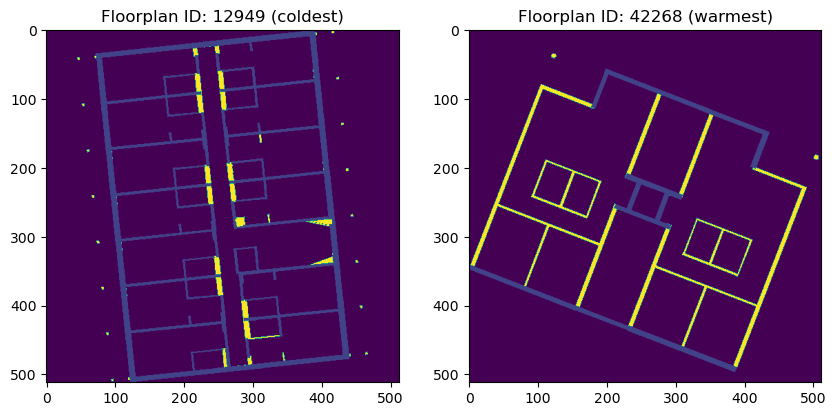

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
id1 = 12949
plt.imshow(load_floorplan(path, id1))
plt.title(f"Floorplan ID: {id1} (coldest)")
plt.subplot(1,2,2)
id2 = 42268
plt.imshow(load_floorplan(path, id2))
plt.title(f"Floorplan ID: {id2} (warmest)")
plt.savefig('floorplans_side_by_side.pdf')